# Pipeline de Segmentação de Células

Este notebook é a demonstração principal do projeto de Processamento Digital de Imagens. Ele organiza as etapas implementadas em `src/` em uma pipeline configurável para segmentar automaticamente células em imagens microscópicas reais.

A execução acompanha a imagem original até a máscara binária final, passando por pré-processamento, filtragem no domínio da frequência, superpixels, segmentação, morfologia matemática e avaliação quantitativa quando existir máscara de referência.



## 1. Imports e Caminhos

A OpenCV é usada apenas indiretamente pelo carregador de imagens. As etapas centrais de cor, limiarização, SLIC, morfologia e componentes conexos usam as funções próprias do projeto.



In [28]:
from copy import deepcopy
import csv
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import (
    describe_image,
    find_matching_mask,
    list_image_files,
    load_color_image,
    load_grayscale_image,
    validate_image_mask_pair,
)
from src.frequency import (
    apply_high_pass_filter,
    apply_low_pass_filter,
    compute_fft,
    magnitude_spectrum,
)
from src.morphology import (
    binary_closing,
    binary_opening,
    connected_components,
    create_structuring_element,
    dilate_binary,
    erode_binary,
    fill_holes,
    filter_components_by_area,
    remove_small_objects,
)
from src.preprocessing import (
    convert_color_spaces,
    equalize_histogram,
    normalize_to_uint8,
)
from src.segmentation import (
    build_binary_mask_from_labels,
    mask_to_visual,
    overlay_binary_mask,
)
from src.superpixel_features import (
    compute_superpixel_features,
    feature_map_to_uint8,
    feature_values_to_map,
    get_feature_values,
)
from src.superpixels import overlay_superpixel_boundaries, slic
from src.thresholding import (
    classify_superpixels_by_rules,
    classify_superpixels_by_threshold,
    otsu_threshold_from_values,
)

print(f"Raiz do projeto: {project_root}")



Raiz do projeto: C:\Users\joaov\Documents\Projetos\digital-image-processing\image-segmentation-pipeline


## 2. Configuração da Pipeline

Esta célula concentra os parâmetros do experimento. Para testar outra imagem, canal, raio de filtro, número de superpixels ou sequência morfológica, altere apenas este dicionário e a lista `PIPELINE_STEPS`.

Os caminhos relativos abaixo são resolvidos a partir da raiz do projeto.



In [29]:
PIPELINE_CONFIG = {
    "image_dir": "data/samples/images",
    "mask_dir": "data/samples/masks",
    "image_names": [
        "BloodImage_00340.jpg",
        "BloodImage_00367.jpg",
        "BloodImage_00368.jpg",
    ],
    "max_images": 3,

    "preprocessing": {
        "color_space": "HSV",
        "selected_channel": "S",
        "normalize": True,
        "equalize": False,
    },

    "frequency_filter": {
        "enabled": True,
        "type": "low_pass",
        "radius": 35,
    },

    "superpixels": {
        "enabled": True,
        "input_color_space": "LAB",
        "num_superpixels": 450,
        "compactness": 10,
        "max_iterations": 10,
        "boundary_thickness": 1,
    },

    "segmentation": {
        "method": "otsu_superpixel",
        "feature": "mean_s",
        "bins": 128,
        "threshold": None,
        "threshold_percentile": 60,
        "threshold_offset": 0,
        "object_condition": "greater_equal",
        "rules": [
            {"feature": "mean_s", "threshold": 80, "operator": ">="},
            {"feature": "mean_l", "threshold": 210, "operator": "<="},
        ],
        "rule_logic": "and",
    },

    "morphology": {
        "enabled": True,
        "operations": ["opening", "closing", "fill_holes", "remove_small_objects"],
        "structuring_element": "disk",
        "kernel_size": 3,
        "iterations": 1,
        "fill_holes": True,
        "remove_small_objects": True,
        "min_object_area": 80,
        "max_object_area": None,
        "connectivity": 8,
    },

    "evaluation": {
        "enabled": True,
        "metrics": [
            "iou",
            "dice",
            "precision",
            "recall",
            "pixel_accuracy",
            "object_count",
            "foreground_ratio",
        ],
    },

    "output": {
        "save_figures": True,
        "save_masks": True,
        "save_intermediate_images": True,
        "output_dir": "outputs/pipeline_tests",
    },
}



## 3. Ordem das Etapas

A lista abaixo define o fluxo de execução. Remover uma etapa desativa seu processamento; trocar a ordem permite testar hipóteses diferentes para o relatório.



In [30]:
PIPELINE_STEPS = [
    "load_image",
    "preprocess",
    "frequency_filter",
    "superpixels",
    "segment",
    "morphology",
    "evaluate",
    "save_outputs",
]



## 4. Funções Auxiliares de Preparação

Estas funções resolvem caminhos, selecionam canais e cuidam de pequenas tarefas de configuração. O processamento pesado continua nos módulos de `src/`.



In [31]:
CHANNELS_BY_COLOR_SPACE = {
    "rgb": ("R", "G", "B"),
    "hsv": ("H", "S", "V"),
    "lab": ("L", "A", "B"),
}


def resolve_project_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    return project_root / path


def resolve_image_path(image_name_or_path, config):
    path = Path(image_name_or_path)

    if path.exists():
        return path

    project_candidate = resolve_project_path(path)
    if project_candidate.exists():
        return project_candidate

    image_dir = resolve_project_path(config["image_dir"])
    return image_dir / path.name


def get_image_paths(config):
    image_names = config.get("image_names") or []
    max_images = config.get("max_images")

    if image_names:
        image_paths = [resolve_image_path(image_name, config) for image_name in image_names]
    else:
        image_paths = list_image_files(resolve_project_path(config["image_dir"]))

    if max_images is not None:
        image_paths = image_paths[: int(max_images)]

    return image_paths


def get_color_space_image(color_spaces, color_space):
    key = color_space.lower()
    if key not in color_spaces:
        valid_options = ", ".join(sorted(color_spaces.keys()))
        raise ValueError(f"Espaço de cor inválido: {color_space}. Opções: {valid_options}")
    return color_spaces[key]


def select_channel(color_spaces, color_space, selected_channel):
    color_space_key = color_space.lower()

    if color_space_key in ("gray", "grayscale", "cinza"):
        return color_spaces["gray"].copy()

    image = get_color_space_image(color_spaces, color_space_key)
    selected_channel = selected_channel.upper()
    channel_names = CHANNELS_BY_COLOR_SPACE.get(color_space_key)

    if channel_names is None:
        raise ValueError(f"Seleção de canal não configurada para {color_space}")

    if selected_channel not in channel_names:
        valid_channels = ", ".join(channel_names)
        raise ValueError(f"Canal inválido: {selected_channel}. Opções para {color_space}: {valid_channels}")

    channel_index = channel_names.index(selected_channel)
    return image[:, :, channel_index].copy()


def normalize_condition(condition):
    aliases = {
        "greater_equal": "greater_equal",
        "greater": "greater",
        "less_equal": "less_equal",
        "less": "less",
        ">=": "greater_equal",
        ">": "greater",
        "<=": "less_equal",
        "<": "less",
    }
    if condition not in aliases:
        raise ValueError("Condição deve ser greater_equal, greater, less_equal ou less.")
    return aliases[condition]


def apply_condition(values, threshold, condition):
    condition = normalize_condition(condition)
    if condition == "greater_equal":
        return values >= threshold
    if condition == "greater":
        return values > threshold
    if condition == "less_equal":
        return values <= threshold
    if condition == "less":
        return values < threshold
    raise ValueError(f"Condição inválida: {condition}")


def set_nested_value(config, parameter_path, value):
    keys = parameter_path.split(".") if isinstance(parameter_path, str) else list(parameter_path)
    target = config
    for key in keys[:-1]:
        target = target[key]
    target[keys[-1]] = value



## 5. Funções da Pipeline

A função `run_pipeline` executa uma imagem e retorna um dicionário com a imagem original, intermediários, máscara inicial, máscara final, métricas e configuração usada.



In [32]:
def load_reference_mask(image_path, original_image, config):
    mask_dir = resolve_project_path(config["mask_dir"])
    reference_path = find_matching_mask(image_path, mask_dir)

    if reference_path is None:
        return None, None

    reference_mask = load_grayscale_image(reference_path)
    if not validate_image_mask_pair(original_image, reference_mask):
        return None, reference_path

    return (reference_mask > 0).astype(np.uint8), reference_path


def preprocess_image(original_image, config):
    color_spaces = convert_color_spaces(original_image)
    preprocessing_config = config["preprocessing"]

    selected = select_channel(
        color_spaces,
        preprocessing_config["color_space"],
        preprocessing_config["selected_channel"],
    )

    if preprocessing_config.get("normalize", False):
        selected = normalize_to_uint8(selected)

    if preprocessing_config.get("equalize", False):
        selected = equalize_histogram(selected)

    return selected, color_spaces


def apply_frequency_stage(preprocessed_image, config):
    frequency_config = config["frequency_filter"]
    fft_shifted = compute_fft(preprocessed_image)
    fft_magnitude = magnitude_spectrum(fft_shifted)

    if not frequency_config.get("enabled", False):
        return preprocessed_image.copy(), fft_magnitude

    radius = int(frequency_config["radius"])
    filter_type = frequency_config["type"].lower()

    if filter_type == "low_pass":
        filtered_image = apply_low_pass_filter(preprocessed_image, radius)
    elif filter_type == "high_pass":
        filtered_image = apply_high_pass_filter(preprocessed_image, radius)
    else:
        raise ValueError("frequency_filter.type deve ser 'low_pass' ou 'high_pass'.")

    return filtered_image, fft_magnitude


def generate_superpixels(result, config):
    superpixel_config = config["superpixels"]
    if not superpixel_config.get("enabled", False):
        return None, None

    input_color_space = superpixel_config.get("input_color_space", "LAB").lower()
    if input_color_space == "preprocessed":
        slic_input = result.get("frequency_filtered", result["preprocessed"])
    else:
        slic_input = get_color_space_image(result["color_spaces"], input_color_space)

    labels = slic(
        slic_input,
        num_superpixels=int(superpixel_config["num_superpixels"]),
        m=float(superpixel_config["compactness"]),
        max_iter=int(superpixel_config["max_iterations"]),
    )
    overlay = overlay_superpixel_boundaries(
        result["original"],
        labels,
        boundary_color=(255, 0, 0),
        alpha=0.85,
        thickness=int(superpixel_config.get("boundary_thickness", 1)),
    )
    return labels, overlay


def segment_without_superpixels(result, config):
    segmentation_config = config["segmentation"]
    source = result.get("frequency_filtered", result["preprocessed"])
    values = source.astype(np.float64).ravel()
    method = segmentation_config.get("method", "otsu_pixel")
    condition = segmentation_config.get("object_condition", "greater_equal")

    if method == "threshold_pixel" and segmentation_config.get("threshold") is not None:
        threshold = float(segmentation_config["threshold"])
    else:
        threshold = otsu_threshold_from_values(values, bins=int(segmentation_config.get("bins", 128)))

    threshold += float(segmentation_config.get("threshold_offset", 0))
    mask = apply_condition(source.astype(np.float64), threshold, condition).astype(np.uint8)

    return mask, {
        "method": method,
        "threshold": float(threshold),
        "feature": "pixel_intensity",
        "selected_labels": None,
    }


def segment_superpixels(result, config):
    segmentation_config = config["segmentation"]
    labels = result["superpixel_labels"]
    feature_name = segmentation_config.get("feature", "mean_s")
    condition = segmentation_config.get("object_condition", "greater_equal")
    method = segmentation_config.get("method", "otsu_superpixel")

    gray_for_features = result.get("frequency_filtered", result["preprocessed"])
    features = compute_superpixel_features(
        result["color_spaces"]["hsv"],
        result["color_spaces"]["lab"],
        labels,
        gray_image=gray_for_features,
    )

    if method == "rules":
        selected_labels = classify_superpixels_by_rules(
            features,
            segmentation_config.get("rules", []),
            logic=segmentation_config.get("rule_logic", "and"),
        )
        threshold = None
    else:
        values = get_feature_values(features, feature_name)

        if method == "threshold_superpixel" and segmentation_config.get("threshold") is not None:
            threshold = float(segmentation_config["threshold"])
        elif method == "threshold_superpixel":
            threshold = float(np.percentile(values, segmentation_config.get("threshold_percentile", 60)))
        else:
            threshold = otsu_threshold_from_values(
                values,
                bins=int(segmentation_config.get("bins", 128)),
            )

        threshold += float(segmentation_config.get("threshold_offset", 0))
        selected_labels = classify_superpixels_by_threshold(
            features,
            feature_name,
            threshold,
            direction=normalize_condition(condition),
        )

    initial_mask = build_binary_mask_from_labels(labels, selected_labels)
    feature_map = feature_values_to_map(labels, features, feature_name)

    return initial_mask, {
        "method": method,
        "feature": feature_name,
        "threshold": None if threshold is None else float(threshold),
        "selected_labels": selected_labels,
        "selected_label_count": len(selected_labels),
        "features": features,
        "feature_map": feature_map,
    }


def apply_morphology(initial_mask, config):
    morphology_config = config["morphology"]
    history = {"input": initial_mask.copy()}

    if not morphology_config.get("enabled", False):
        return initial_mask.copy(), history

    current = (initial_mask > 0).astype(np.uint8)
    element = create_structuring_element(
        morphology_config.get("structuring_element", "disk"),
        int(morphology_config.get("kernel_size", 3)),
    )
    iterations = int(morphology_config.get("iterations", 1))
    connectivity = int(morphology_config.get("connectivity", 8))

    for operation in morphology_config.get("operations", []):
        operation = operation.lower()

        if operation in ("erosion", "erode"):
            for _ in range(iterations):
                current = erode_binary(current, element)
        elif operation in ("dilation", "dilate"):
            for _ in range(iterations):
                current = dilate_binary(current, element)
        elif operation == "opening":
            for _ in range(iterations):
                current = binary_opening(current, element)
        elif operation == "closing":
            for _ in range(iterations):
                current = binary_closing(current, element)
        elif operation == "fill_holes":
            if morphology_config.get("fill_holes", True):
                current = fill_holes(current, connectivity=connectivity)
        elif operation in ("remove_small_objects", "area_filter"):
            if morphology_config.get("remove_small_objects", True) or operation == "area_filter":
                min_area = int(morphology_config.get("min_object_area", 0))
                max_area = morphology_config.get("max_object_area")
                if max_area is None:
                    current = remove_small_objects(current, min_area=min_area, connectivity=connectivity)
                else:
                    current = filter_components_by_area(
                        current,
                        min_area=min_area,
                        max_area=int(max_area),
                        connectivity=connectivity,
                    )
        else:
            raise ValueError(f"Operação morfológica desconhecida: {operation}")

        history[operation] = current.copy()

    return current.astype(np.uint8), history


def evaluate_segmentation(final_mask, reference_mask, config):
    evaluation_config = config["evaluation"]
    requested_metrics = set(evaluation_config.get("metrics", []))
    metrics = {"has_reference": reference_mask is not None}

    predicted = (final_mask > 0).astype(np.uint8)
    if "foreground_ratio" in requested_metrics:
        metrics["foreground_ratio"] = float(np.sum(predicted) / predicted.size)

    if "object_count" in requested_metrics:
        _, components = connected_components(
            predicted,
            connectivity=int(config["morphology"].get("connectivity", 8)),
        )
        metrics["object_count"] = int(len(components))

    reference_metrics = {"iou", "dice", "precision", "recall", "pixel_accuracy"}
    if reference_mask is None:
        for metric_name in sorted(reference_metrics & requested_metrics):
            metrics[metric_name] = None
        return metrics

    reference = (reference_mask > 0).astype(np.uint8)
    predicted_bool = predicted.astype(bool)
    reference_bool = reference.astype(bool)

    intersection = int(np.logical_and(predicted_bool, reference_bool).sum())
    union = int(np.logical_or(predicted_bool, reference_bool).sum())
    predicted_area = int(predicted_bool.sum())
    reference_area = int(reference_bool.sum())
    true_negative = int(np.logical_and(~predicted_bool, ~reference_bool).sum())
    false_positive = int(np.logical_and(predicted_bool, ~reference_bool).sum())
    false_negative = int(np.logical_and(~predicted_bool, reference_bool).sum())

    if "iou" in requested_metrics:
        metrics["iou"] = float(intersection / union) if union > 0 else 1.0
    if "dice" in requested_metrics:
        denominator = predicted_area + reference_area
        metrics["dice"] = float((2 * intersection) / denominator) if denominator > 0 else 1.0
    if "precision" in requested_metrics:
        denominator = intersection + false_positive
        metrics["precision"] = float(intersection / denominator) if denominator > 0 else 1.0
    if "recall" in requested_metrics:
        denominator = intersection + false_negative
        metrics["recall"] = float(intersection / denominator) if denominator > 0 else 1.0
    if "pixel_accuracy" in requested_metrics:
        metrics["pixel_accuracy"] = float((intersection + true_negative) / predicted.size)

    return metrics


def run_pipeline(image_path, config, steps):
    """
    Executa a pipeline completa de segmentação para uma imagem.

    Retorna um dicionário com imagem original, intermediários, máscara final,
    métricas e informações úteis para visualização.
    """
    config = deepcopy(config)
    steps = list(steps)
    image_path = resolve_image_path(image_path, config)

    result = {
        "image_name": image_path.name,
        "image_path": str(image_path),
        "config": config,
        "steps": steps,
        "metrics": {},
        "output_paths": {},
        "notes": [],
    }

    for step in steps:
        if step == "load_image":
            original = load_color_image(image_path)
            reference_mask, reference_path = load_reference_mask(image_path, original, config)
            result["original"] = original
            result["image_info"] = describe_image(original)
            result["reference_mask"] = reference_mask
            result["reference_mask_path"] = None if reference_path is None else str(reference_path)

        elif step == "preprocess":
            result["preprocessed"], result["color_spaces"] = preprocess_image(result["original"], config)

        elif step == "frequency_filter":
            result["frequency_filtered"], result["fft_magnitude"] = apply_frequency_stage(
                result["preprocessed"],
                config,
            )

        elif step == "superpixels":
            labels, overlay = generate_superpixels(result, config)
            result["superpixel_labels"] = labels
            result["superpixel_overlay"] = overlay
            result["superpixel_count"] = 0 if labels is None else int(len(np.unique(labels)))

        elif step == "segment":
            if result.get("superpixel_labels") is None:
                initial_mask, segmentation_info = segment_without_superpixels(result, config)
            else:
                initial_mask, segmentation_info = segment_superpixels(result, config)

            result["initial_mask"] = initial_mask
            result["segmentation_info"] = segmentation_info

        elif step == "morphology":
            final_mask, morphology_history = apply_morphology(result["initial_mask"], config)
            result["final_mask"] = final_mask
            result["morphology_history"] = morphology_history

        elif step == "evaluate":
            if not config["evaluation"].get("enabled", False):
                continue
            current_mask = result.get("final_mask", result.get("initial_mask"))
            result["metrics"] = evaluate_segmentation(current_mask, result.get("reference_mask"), config)

        elif step == "save_outputs":
            result["output_paths"] = save_pipeline_outputs(result, config)

        else:
            raise ValueError(f"Etapa desconhecida na pipeline: {step}")

    if "initial_mask" in result and "final_mask" not in result:
        result["final_mask"] = result["initial_mask"].copy()

    return result


def run_pipeline_for_images(image_names, config, steps):
    image_paths = [resolve_image_path(image_name, config) for image_name in image_names]
    results = []
    for image_path in image_paths[: int(config.get("max_images", len(image_paths)))]:
        print(f"Executando pipeline: {image_path.name}")
        results.append(run_pipeline(image_path, config, steps))
    return results



## 6. Visualização, Salvamento e Métricas

Estas funções organizam os resultados em grades visuais, salvam os artefatos importantes e produzem uma tabela simples de métricas sem depender de bibliotecas adicionais.



In [33]:
def plot_image_grid(images, titles, cmaps=None, cols=4, figsize=None, save_path=None, show=True):
    if not images:
        raise ValueError("A lista de imagens está vazia.")

    rows = int(np.ceil(len(images) / cols))
    if figsize is None:
        figsize = (4 * cols, 4 * rows)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for index, image in enumerate(images):
        cmap = None if cmaps is None else cmaps[index]
        axes[index].imshow(image, cmap=cmap)
        axes[index].set_title(titles[index])
        axes[index].axis("off")

    for axis in axes[len(images):]:
        axis.axis("off")

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes


def collect_pipeline_visuals(result):
    images = [result["original"]]
    titles = ["Original"]
    cmaps = [None]

    if "preprocessed" in result:
        images.append(result["preprocessed"])
        titles.append("Canal preprocessado")
        cmaps.append("gray")

    if "fft_magnitude" in result:
        images.append(result["fft_magnitude"])
        titles.append("Magnitude FFT")
        cmaps.append("gray")

    if "frequency_filtered" in result:
        images.append(result["frequency_filtered"])
        titles.append("Filtro de frequência")
        cmaps.append("gray")

    if result.get("superpixel_overlay") is not None:
        images.append(result["superpixel_overlay"])
        titles.append("Superpixels")
        cmaps.append(None)

    segmentation_info = result.get("segmentation_info", {})
    feature_map = segmentation_info.get("feature_map")
    if feature_map is not None:
        images.append(feature_map_to_uint8(feature_map, normalize=True))
        titles.append(f"Mapa {segmentation_info.get('feature', 'atributo')}")
        cmaps.append("magma")

    if "initial_mask" in result:
        images.append(mask_to_visual(result["initial_mask"]))
        titles.append("Máscara inicial")
        cmaps.append("gray")

    if "final_mask" in result:
        images.append(mask_to_visual(result["final_mask"]))
        titles.append("Máscara final")
        cmaps.append("gray")
        images.append(overlay_binary_mask(result["original"], result["final_mask"], color=(0, 255, 0), alpha=0.35))
        titles.append("Overlay final")
        cmaps.append(None)

    if result.get("reference_mask") is not None:
        images.append(mask_to_visual(result["reference_mask"]))
        titles.append("Ground truth")
        cmaps.append("gray")

    return images, titles, cmaps


def show_pipeline_result(result, save_path=None, show=True, verbose=True):
    images, titles, cmaps = collect_pipeline_visuals(result)
    if verbose:
        title_suffix = result.get("image_name", "imagem")
        print(f"Resultado: {title_suffix}")
        segmentation_info = result.get("segmentation_info", {})
        if segmentation_info:
            print(
                "Segmentação: "
                f"{segmentation_info.get('method')} | "
                f"atributo={segmentation_info.get('feature')} | "
                f"limiar={segmentation_info.get('threshold')}"
            )
        if result.get("metrics"):
            print(f"Métricas: {result['metrics']}")

    return plot_image_grid(
        images,
        titles,
        cmaps=cmaps,
        cols=4,
        figsize=(18, 10),
        save_path=save_path,
        show=show,
    )


def compare_pipeline_results(results, save_path=None, show=True):
    images = []
    titles = []
    for result in results:
        final_mask = result.get("final_mask", result.get("initial_mask"))
        images.append(overlay_binary_mask(result["original"], final_mask, color=(0, 255, 0), alpha=0.35))
        object_count = result.get("metrics", {}).get("object_count")
        if object_count is None:
            titles.append(result["image_name"])
        else:
            titles.append(f"{result['image_name']}\nobjetos={object_count}")

    return plot_image_grid(
        images,
        titles,
        cmaps=[None] * len(images),
        cols=min(3, max(1, len(images))),
        figsize=(5 * min(3, max(1, len(images))), 5),
        save_path=save_path,
        show=show,
    )


def to_jsonable(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f"Objeto não serializável: {type(value)}")


def save_image(path, image, cmap=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.imsave(path, image, cmap=cmap)
    return str(path)


def save_pipeline_outputs(result, config):
    output_config = config["output"]
    output_dir = resolve_project_path(output_config["output_dir"])
    image_output_dir = output_dir / Path(result["image_name"]).stem
    image_output_dir.mkdir(parents=True, exist_ok=True)

    paths = {}
    paths["config"] = str(image_output_dir / "config.json")
    with open(paths["config"], "w", encoding="utf-8") as file:
        json.dump(config, file, indent=2, ensure_ascii=False, default=to_jsonable)

    if output_config.get("save_intermediate_images", True):
        paths["original"] = save_image(image_output_dir / "original.png", result["original"])
        if "preprocessed" in result:
            paths["preprocessing"] = save_image(image_output_dir / "preprocessing.png", result["preprocessed"], cmap="gray")
        if "frequency_filtered" in result:
            paths["frequency"] = save_image(image_output_dir / "frequency.png", result["frequency_filtered"], cmap="gray")
        if result.get("superpixel_overlay") is not None:
            paths["superpixels"] = save_image(image_output_dir / "superpixels.png", result["superpixel_overlay"])

    if output_config.get("save_masks", True):
        if "initial_mask" in result:
            paths["initial_mask"] = save_image(
                image_output_dir / "initial_mask.png",
                mask_to_visual(result["initial_mask"]),
                cmap="gray",
            )
        if "final_mask" in result:
            paths["final_mask"] = save_image(
                image_output_dir / "final_mask.png",
                mask_to_visual(result["final_mask"]),
                cmap="gray",
            )
            paths["overlay"] = save_image(
                image_output_dir / "overlay.png",
                overlay_binary_mask(result["original"], result["final_mask"], color=(0, 255, 0), alpha=0.35),
            )

    if result.get("metrics"):
        paths["metrics"] = str(image_output_dir / "metrics.json")
        with open(paths["metrics"], "w", encoding="utf-8") as file:
            json.dump(result["metrics"], file, indent=2, ensure_ascii=False, default=to_jsonable)

    if output_config.get("save_figures", True):
        paths["pipeline_figure"] = str(image_output_dir / "pipeline_steps.png")
        show_pipeline_result(result, save_path=paths["pipeline_figure"], show=False, verbose=False)

    return paths


def summarize_metrics(results, save_path=None):
    rows = []
    for result in results:
        row = {"image_name": result["image_name"]}
        row.update(result.get("metrics", {}))
        rows.append(row)

    if not rows:
        print("Nenhum resultado disponível para resumir.")
        return []

    metric_keys = ["image_name"] + sorted({key for row in rows for key in row if key != "image_name"})

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        with open(save_path, "w", newline="", encoding="utf-8") as file:
            writer = csv.DictWriter(file, fieldnames=metric_keys)
            writer.writeheader()
            writer.writerows(rows)
        print(f"Resumo de métricas salvo em: {save_path}")

    widths = {
        key: max(len(key), *(len(format_metric_value(row.get(key))) for row in rows))
        for key in metric_keys
    }
    header = " | ".join(key.ljust(widths[key]) for key in metric_keys)
    separator = "-+-".join("-" * widths[key] for key in metric_keys)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(format_metric_value(row.get(key)).ljust(widths[key]) for key in metric_keys))

    return rows


def format_metric_value(value):
    if value is None:
        return "-"
    if isinstance(value, float):
        return f"{value:.4f}"
    return str(value)



## 7. Execução em Uma Imagem

Primeiro executamos a pipeline em uma amostra principal. Esta etapa é útil para explicar visualmente a ordem das operações e observar onde a máscara melhora ou piora.



Imagens selecionadas:
- BloodImage_00340.jpg
- BloodImage_00367.jpg
- BloodImage_00368.jpg
Resultado: BloodImage_00340.jpg
Segmentação: otsu_superpixel | atributo=mean_s | limiar=52.634442246086884
Métricas: {'has_reference': False, 'foreground_ratio': 0.025162760416666666, 'object_count': 2, 'dice': None, 'iou': None, 'pixel_accuracy': None, 'precision': None, 'recall': None}


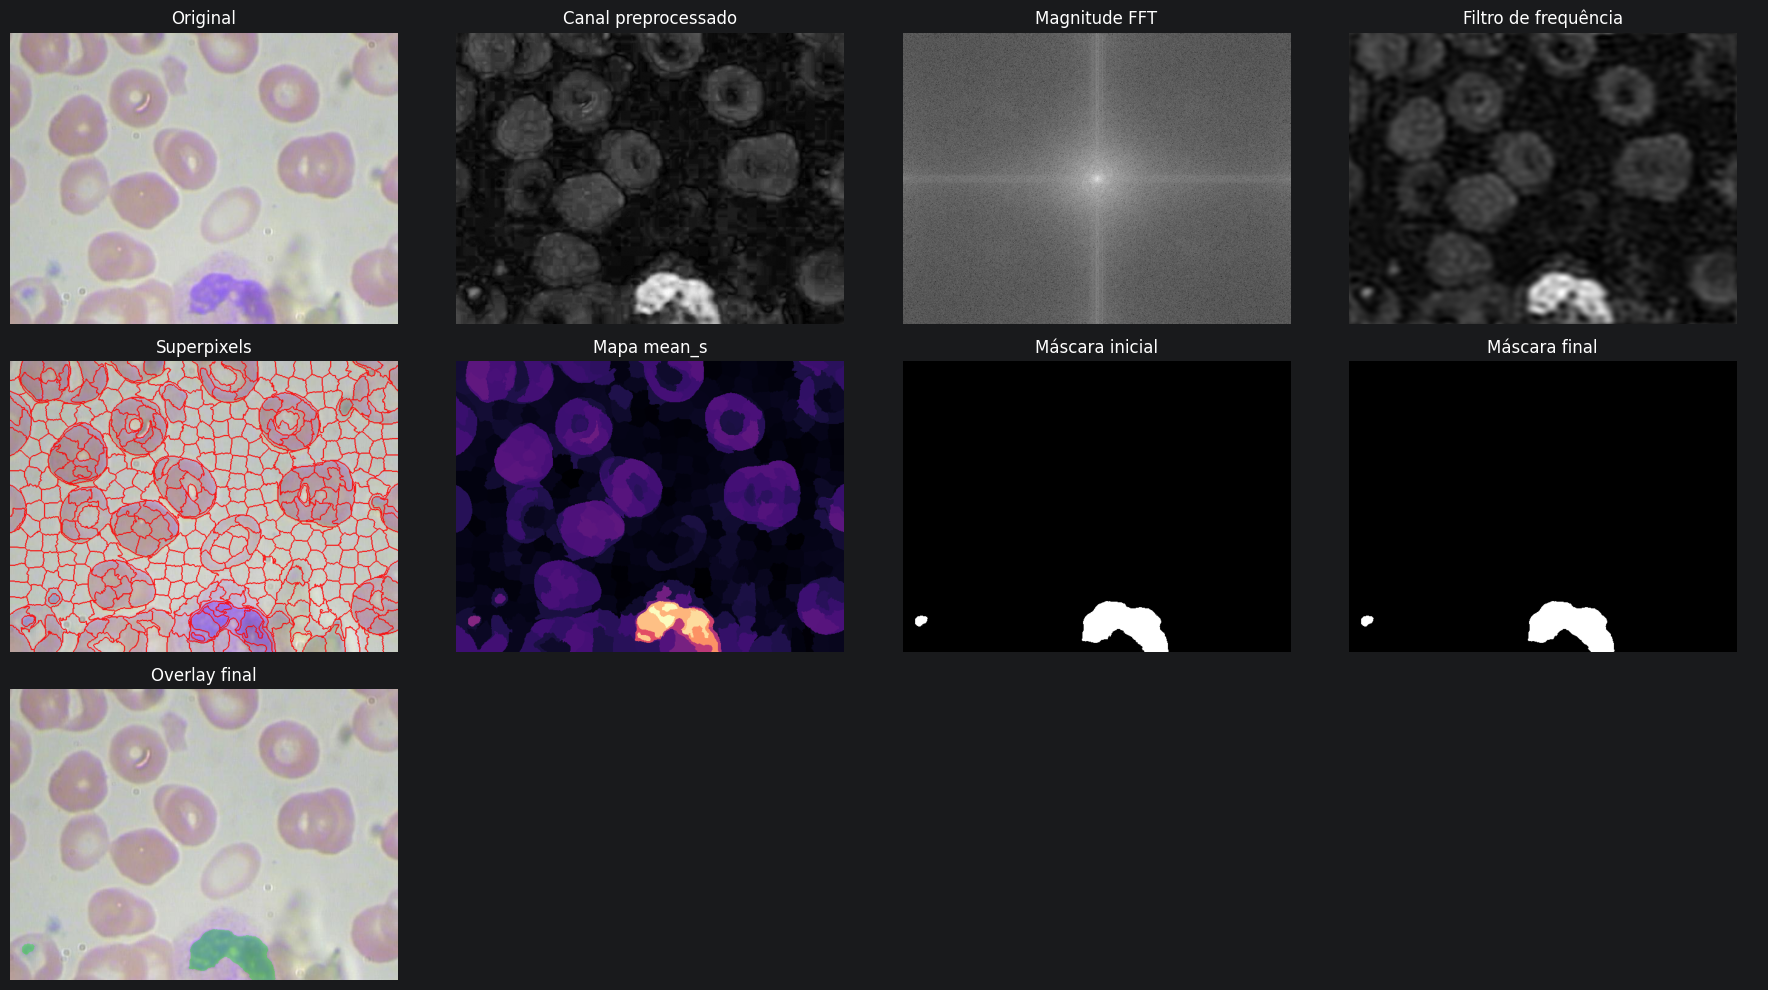

(<Figure size 1800x1000 with 12 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Canal preprocessado'}>,
        <Axes: title={'center': 'Magnitude FFT'}>,
        <Axes: title={'center': 'Filtro de frequência'}>,
        <Axes: title={'center': 'Superpixels'}>,
        <Axes: title={'center': 'Mapa mean_s'}>,
        <Axes: title={'center': 'Máscara inicial'}>,
        <Axes: title={'center': 'Máscara final'}>,
        <Axes: title={'center': 'Overlay final'}>, <Axes: >, <Axes: >,
        <Axes: >], dtype=object))

In [34]:
image_paths = get_image_paths(PIPELINE_CONFIG)
print("Imagens selecionadas:")
for image_path in image_paths:
    print(f"- {image_path.name}")

primary_result = run_pipeline(image_paths[0], PIPELINE_CONFIG, PIPELINE_STEPS)
show_pipeline_result(primary_result)



## 8. Execução em Múltiplas Imagens

Agora aplicamos a mesma configuração em várias imagens para avaliar a estabilidade visual da segmentação.



Executando pipeline: BloodImage_00340.jpg
Executando pipeline: BloodImage_00367.jpg
Executando pipeline: BloodImage_00368.jpg


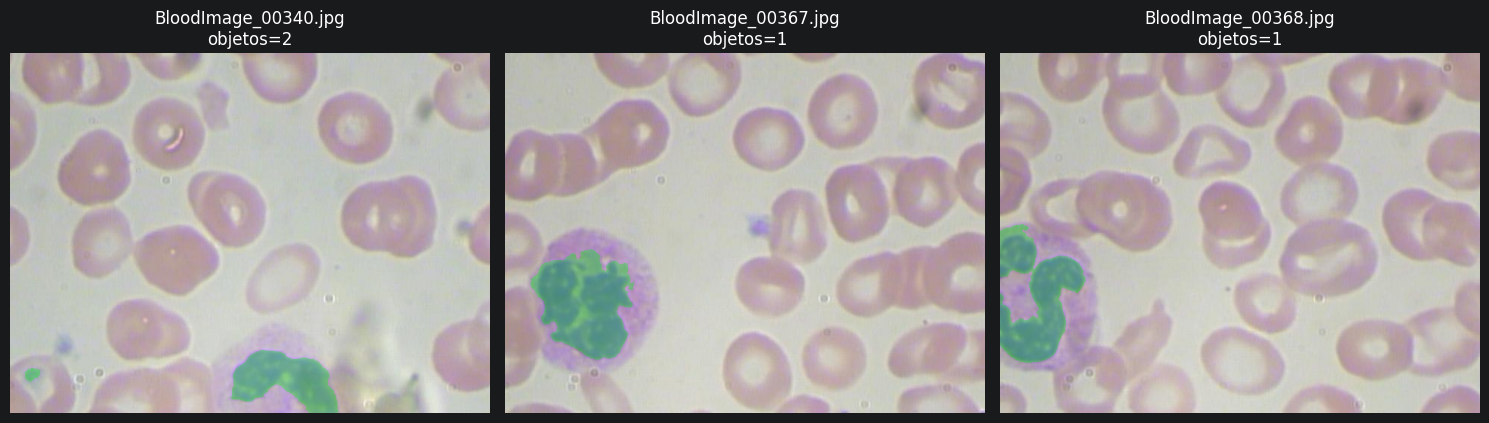

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'BloodImage_00340.jpg\nobjetos=2'}>,
        <Axes: title={'center': 'BloodImage_00367.jpg\nobjetos=1'}>,
        <Axes: title={'center': 'BloodImage_00368.jpg\nobjetos=1'}>],
       dtype=object))

In [48]:
results = run_pipeline_for_images(
    image_names=image_paths,
    config=PIPELINE_CONFIG,
    steps=PIPELINE_STEPS,
)

compare_pipeline_results(results)



## 9. Testes de Parâmetros

Esta seção altera um parâmetro por vez e mostra rapidamente o impacto no overlay final. A função aceita caminhos como `superpixels.num_superpixels`, `frequency_filter.radius` ou `morphology.min_object_area`.



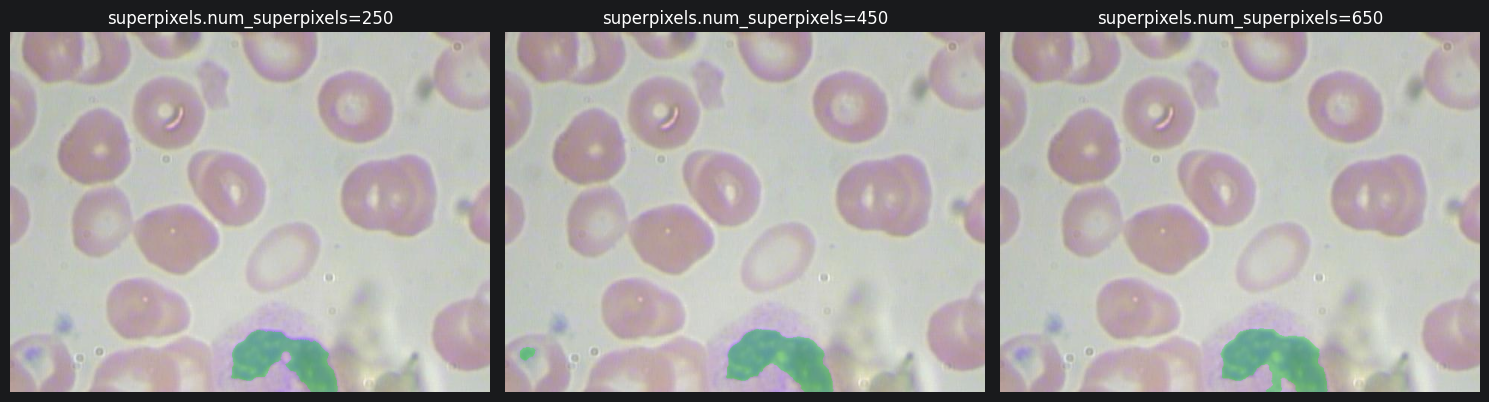

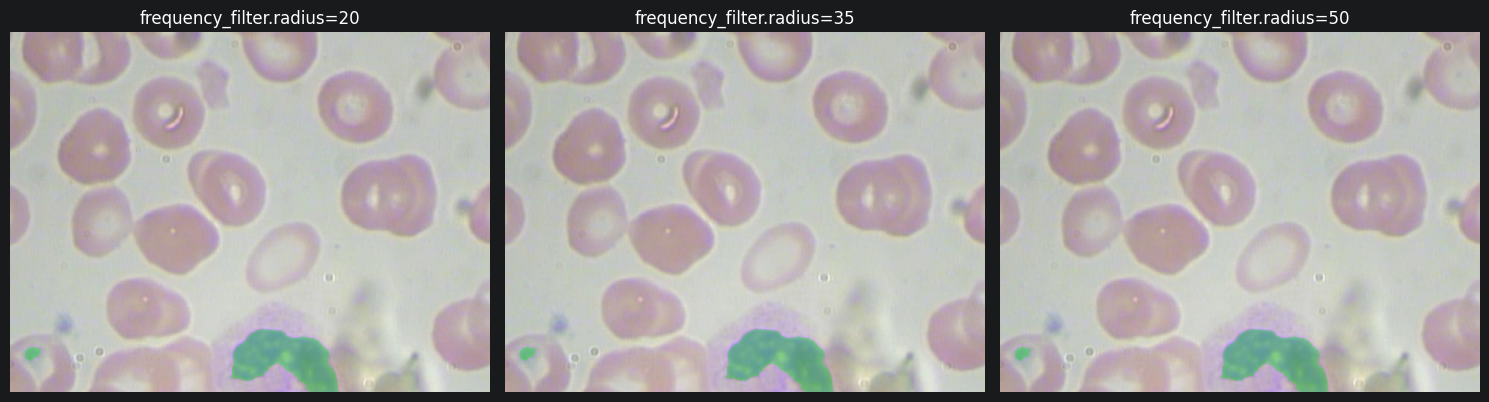

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'frequency_filter.radius=20'}>,
        <Axes: title={'center': 'frequency_filter.radius=35'}>,
        <Axes: title={'center': 'frequency_filter.radius=50'}>],
       dtype=object))

In [36]:
def run_parameter_test(base_config, parameter_path, values, image_name, steps=None):
    test_results = []
    if steps is None:
        steps = [step for step in PIPELINE_STEPS if step != "save_outputs"]

    for value in values:
        test_config = deepcopy(base_config)
        set_nested_value(test_config, parameter_path, value)
        test_config["output"]["save_figures"] = False
        test_config["output"]["save_masks"] = False
        test_config["output"]["save_intermediate_images"] = False

        result = run_pipeline(image_name, test_config, steps)
        result["parameter_label"] = f"{parameter_path}={value}"
        test_results.append(result)

    return test_results


SUPERPIXEL_TESTS = [250, 450, 650]
FREQUENCY_RADIUS_TESTS = [20, 35, 50]

superpixel_test_results = run_parameter_test(
    PIPELINE_CONFIG,
    "superpixels.num_superpixels",
    SUPERPIXEL_TESTS,
    image_paths[0],
)

plot_image_grid(
    images=[
        overlay_binary_mask(result["original"], result["final_mask"], color=(0, 255, 0), alpha=0.35)
        for result in superpixel_test_results
    ],
    titles=[result["parameter_label"] for result in superpixel_test_results],
    cmaps=[None] * len(superpixel_test_results),
    cols=3,
    figsize=(15, 5),
)

frequency_test_results = run_parameter_test(
    PIPELINE_CONFIG,
    "frequency_filter.radius",
    FREQUENCY_RADIUS_TESTS,
    image_paths[0],
)

plot_image_grid(
    images=[
        overlay_binary_mask(result["original"], result["final_mask"], color=(0, 255, 0), alpha=0.35)
        for result in frequency_test_results
    ],
    titles=[result["parameter_label"] for result in frequency_test_results],
    cmaps=[None] * len(frequency_test_results),
    cols=3,
    figsize=(15, 5),
)



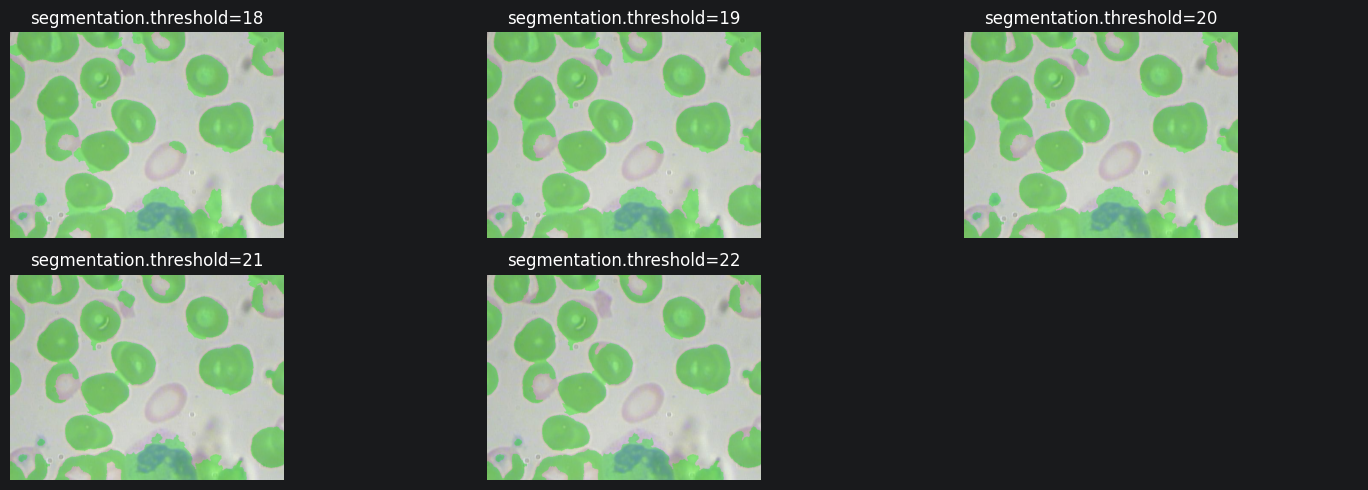

(<Figure size 1500x500 with 6 Axes>,
 array([<Axes: title={'center': 'segmentation.threshold=18'}>,
        <Axes: title={'center': 'segmentation.threshold=19'}>,
        <Axes: title={'center': 'segmentation.threshold=20'}>,
        <Axes: title={'center': 'segmentation.threshold=21'}>,
        <Axes: title={'center': 'segmentation.threshold=22'}>, <Axes: >],
       dtype=object))

In [37]:
threshold_config = deepcopy(PIPELINE_CONFIG)
threshold_config["segmentation"]["method"] = "threshold_superpixel"

threshold_results = run_parameter_test(
    threshold_config,
    "segmentation.threshold",
    [18, 19, 20, 21, 22],
    image_paths[0],
)

plot_image_grid(
    images=[
        overlay_binary_mask(result["original"], result["final_mask"], color=(0, 255, 0), alpha=0.35)
        for result in threshold_results
    ],
    titles=[result["parameter_label"] for result in threshold_results],
    cmaps=[None] * len(threshold_results),
    cols=3,
    figsize=(15, 5),
)

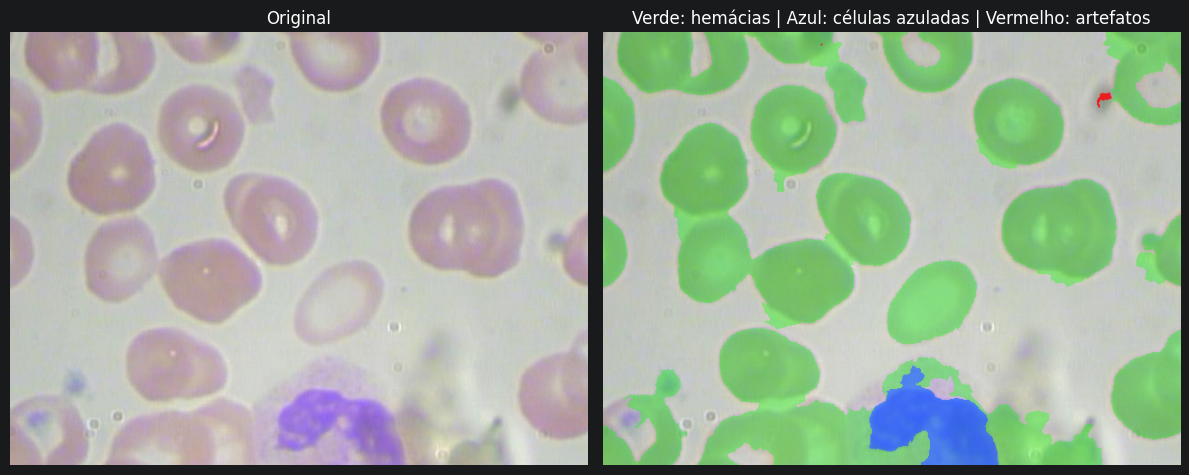

Componentes de hemácias: 15


In [38]:
from importlib import reload
from copy import deepcopy
import numpy as np

import src.thresholding as thresholding_module
import src.morphology as morphology_module
reload(thresholding_module)
reload(morphology_module)

from src.thresholding import (
    classify_pixels_by_rules,
    classify_superpixels_by_rules,
)
from src.segmentation import build_binary_mask_from_labels, overlay_binary_mask
from src.morphology import (
    binary_closing,
    connected_components,
    create_structuring_element,
    fill_holes,
    remove_small_objects,
)

config = deepcopy(PIPELINE_CONFIG)
config["segmentation"]["method"] = "threshold_superpixel"
config["segmentation"]["threshold"] = 20
config["superpixels"]["num_superpixels"] = 450
config["superpixels"]["compactness"] = 10

result = run_pipeline(
    image_paths[0],
    config,
    [step for step in PIPELINE_STEPS if step != "save_outputs"],
)

labels = result["superpixel_labels"]
features = result["segmentation_info"]["features"]
hsv = result["color_spaces"]["hsv"]

def superpixel_mask(rules):
    selected = classify_superpixels_by_rules(features, rules, logic="and")
    return build_binary_mask_from_labels(labels, selected)

red_base = superpixel_mask([
    {"feature": "mean_s", "threshold": 20, "operator": ">="},
    {"feature": "mean_b", "threshold": 115, "operator": ">="},
])

red_pale = superpixel_mask([
    {"feature": "mean_a", "threshold": 129, "operator": ">="},
    {"feature": "mean_b", "threshold": 125, "operator": ">="},
])

blue_raw = superpixel_mask([
    {"feature": "mean_s", "threshold": 45, "operator": ">="},
    {"feature": "mean_b", "threshold": 115, "operator": "<="},
])

element = create_structuring_element("disk", 3)

red_mask = ((red_base > 0) | (red_pale > 0)).astype(np.uint8)
red_mask = fill_holes(binary_closing(red_mask, element), connectivity=8)
red_mask = remove_small_objects(red_mask, min_area=900, connectivity=8)

blue_mask = remove_small_objects(blue_raw, min_area=500, connectivity=8)
red_mask[blue_mask > 0] = 0

dark_mask = classify_pixels_by_rules(
    {"s": hsv[:, :, 1], "v": hsv[:, :, 2]},
    [
        {"channel": "v", "threshold": 160, "operator": "<="},
        {"channel": "s", "threshold": 10, "operator": "<="},
    ],
)
dark_mask = remove_small_objects(
    binary_closing(dark_mask, element),
    min_area=4,
    connectivity=8,
)

combined = overlay_binary_mask(result["original"], red_mask, (0, 255, 0), 0.35)
combined = overlay_binary_mask(combined, blue_mask, (0, 100, 255), 0.60)
combined = overlay_binary_mask(combined, dark_mask, (255, 0, 0), 0.80)

plot_image_grid(
    images=[result["original"], combined],
    titles=["Original", "Verde: hemácias | Azul: células azuladas | Vermelho: artefatos"],
    cols=2,
    figsize=(12, 5),
)

_, red_components = connected_components(red_mask, connectivity=8)
print("Componentes de hemácias:", len(red_components))

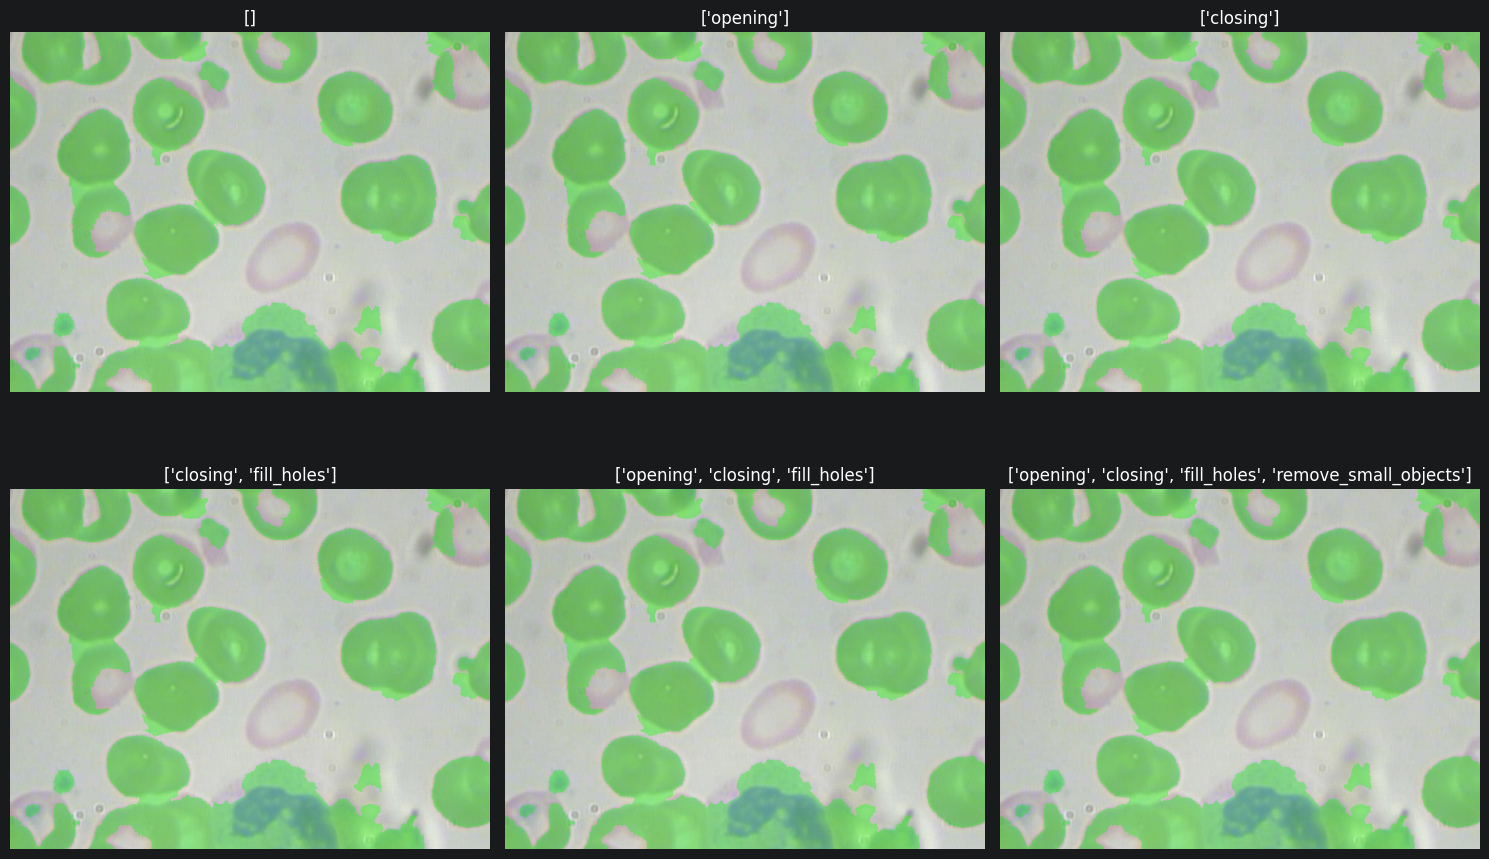

(<Figure size 1500x1000 with 6 Axes>,
 array([<Axes: title={'center': '[]'}>,
        <Axes: title={'center': "['opening']"}>,
        <Axes: title={'center': "['closing']"}>,
        <Axes: title={'center': "['closing', 'fill_holes']"}>,
        <Axes: title={'center': "['opening', 'closing', 'fill_holes']"}>,
        <Axes: title={'center': "['opening', 'closing', 'fill_holes', 'remove_small_objects']"}>],
       dtype=object))

In [39]:
operation_tests = [
    [],
    ["opening"],
    ["closing"],
    ["closing", "fill_holes"],
    ["opening", "closing", "fill_holes"],
    ["opening", "closing", "fill_holes", "remove_small_objects"],
]

results = []

for operations in operation_tests:
    config = deepcopy(PIPELINE_CONFIG)
    config["segmentation"]["method"] = "threshold_superpixel"
    config["segmentation"]["threshold"] = 20
    config["morphology"]["operations"] = operations

    result = run_pipeline(
        image_paths[0],
        config,
        [step for step in PIPELINE_STEPS if step != "save_outputs"],
    )

    results.append(result)

plot_image_grid(
    images=[
        overlay_binary_mask(
            result["original"],
            result["final_mask"],
            color=(0, 255, 0),
            alpha=0.35,
        )
        for result in results
    ],
    titles=[str(operations) or "sem morfologia" for operations in operation_tests],
    cols=3,
    figsize=(15, 10),
)

In [47]:
labels = result["superpixel_labels"]
features = result["segmentation_info"]["features"]

def superpixel_mask(rules):
    selected = classify_superpixels_by_rules(features, rules, logic="and")
    return build_binary_mask_from_labels(labels, selected)

# Base: hemácias bem visíveis
red_base = superpixel_mask([
    {"feature": "mean_s", "threshold": 20, "operator": ">="},
    {"feature": "mean_b", "threshold": 115, "operator": ">="},
])

# Complemento: hemácias pálidas
red_pale = superpixel_mask([
    {"feature": "mean_a", "threshold": 129, "operator": ">="},
    {"feature": "mean_b", "threshold": 125, "operator": ">="},
])

# Exclusão: leucócito e regiões azuladas
blue_exclusion = superpixel_mask([
    {"feature": "mean_s", "threshold": 15, "operator": ">="},
    {"feature": "mean_b", "threshold": 120, "operator": "<="},
])

element = create_structuring_element("disk", 3)

red_mask = ((red_base > 0) | (red_pale > 0)).astype(np.uint8)
red_mask[blue_exclusion > 0] = 0

red_mask = binary_closing(red_mask, element)
red_mask = fill_holes(red_mask, connectivity=8)
red_mask = remove_small_objects(red_mask, min_area=900, connectivity=8)

In [41]:
component_labels, components = connected_components(red_mask, connectivity=8)

instances, watershed_markers, distance_map = watershed_instances(
    red_mask,
    erosion_iterations=6,
    connectivity=8,
)

instance_ids = sorted(set(instances.ravel()) - {0, -1})

print("Componentes antes do watershed:", len(components))
print("Hemácias após watershed:", len(instance_ids))

Componentes antes do watershed: 16
Hemácias após watershed: 22


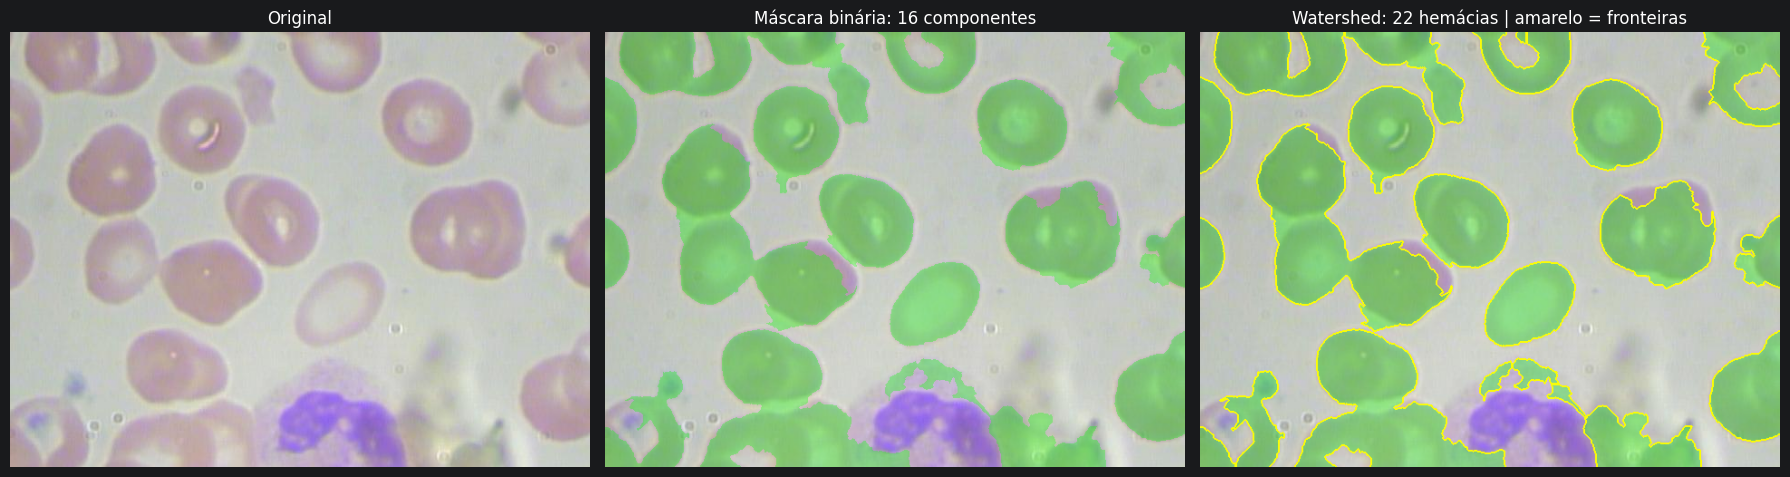

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Máscara binária: 16 componentes'}>,
        <Axes: title={'center': 'Watershed: 22 hemácias | amarelo = fronteiras'}>],
       dtype=object))

In [42]:
mask_overlay = overlay_binary_mask(
    result["original"],
    red_mask,
    color=(0, 255, 0),
    alpha=0.32,
)

watershed_overlay = overlay_instance_boundaries(
    mask_overlay,
    instances,
    color=(255, 255, 0),
    alpha=0.95,
)

plot_image_grid(
    images=[result["original"], mask_overlay, watershed_overlay],
    titles=[
        "Original",
        f"Máscara binária: {len(components)} componentes",
        f"Watershed: {len(instance_ids)} hemácias | amarelo = fronteiras",
    ],
    cols=3,
    figsize=(18, 5),
)

In [44]:
element = np.ones((3, 3), dtype=np.uint8)

red_mask = binary_opening(red_mask, element)   # quebra pontes estreitas
red_mask = binary_closing(red_mask, element)   # corrige pequenas falhas
red_mask = fill_holes(red_mask, connectivity=8)
red_mask = remove_small_objects(red_mask, min_area=900, connectivity=8)

In [45]:
instances, markers, distance_map = watershed_instances(
    red_mask,
    erosion_iterations=6,
    connectivity=8,
)

separated_red_mask = (instances > 0).astype(np.uint8)

num_hemacias = len(np.unique(instances[instances > 0]))
print("Hemácias separadas:", num_hemacias)

Hemácias separadas: 21


In [46]:
overlay = overlay_instance_boundaries(
    original,
    instances,
    color=(255, 255, 0),
)

NameError: name 'original' is not defined

## 10. Avaliação e Registro dos Resultados

Quando houver máscaras de referência em `data/samples/masks`, com o mesmo nome-base da imagem, as métricas IoU, Dice, precisão, recall e acurácia por pixel são calculadas. Mesmo sem referência, a pipeline registra contagem de objetos e proporção de primeiro plano.



In [ ]:
metrics_summary_path = resolve_project_path(PIPELINE_CONFIG["output"]["output_dir"]) / "metrics_summary.csv"
metrics_rows = summarize_metrics(results, save_path=metrics_summary_path)

print("\nDiretórios de saída por imagem:")
for result in results:
    output_paths = result.get("output_paths", {})
    output_dir = Path(output_paths.get("config", "")).parent if output_paths else None
    print(f"- {result['image_name']}: {output_dir}")



## 11. Discussão Final dos Resultados

Registre aqui as observações para o relatório e para a apresentação:

- O canal usado no pré-processamento separou bem células e fundo?
- O filtro de frequência suavizou ruído sem apagar bordas importantes?
- A quantidade de superpixels preservou os contornos das células?
- O atributo escolhido para segmentação foi estável entre imagens?
- A sequência morfológica removeu ruído sem unir objetos distintos?
- As métricas, quando houver ground truth, confirmam a avaliação visual?

Ajustes recomendados para novos testes: variar `preprocessing.selected_channel`, `frequency_filter.radius`, `superpixels.num_superpixels`, `segmentation.feature`, `segmentation.threshold_offset` e `morphology.min_object_area`.